# Cached Prediction EDA (Raw Truth Mixed-Space)

Streamlined analysis notebook for cached LORO outputs with all-genes model fits, evaluated against native GTEx truth using mixed-space correlation analyses.

In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.results_eda import *


In [2]:
import importlib
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)

<module 'src.eval_utils.results_eda' from '/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py'>

In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    naive_cache_dirname='naive',
    dlam_cache_dirname='dlam',
    plam_cache_dirname='plam',
)
CFG
print('analysis scope:', CFG.gene_scope)
print('mixed-space raw truth evaluation:', True)

analysis scope: allgenes
mixed-space raw truth evaluation: True


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 318
genes: 13618
parcels: 150


In [5]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(10)


n (subjects in pool) = 318; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,10,LH-Ca,caudate (basal ganglia),279,279,LH-Ca: caudate (basal ganglia)
1,18,LH-NAC,nucleus accumbens (basal ganglia),273,273,LH-NAC: nucleus accumbens (basal ganglia)
2,5,Cerebellar_Region5,cerebellar hemisphere,262,262,Cerebellar_Region5: cerebellar hemisphere
3,38,LH_Default_PFC_5,frontal cortex (ba9),252,252,LH_Default_PFC_5: frontal cortex (ba9)
4,0,Cerebellar_Region1,cerebellum,251,251,Cerebellar_Region1: cerebellum
5,19,LH-Pu,putamen (basal ganglia),250,250,LH-Pu: putamen (basal ganglia)
6,16,LH-HTH,hypothalamus,242,242,LH-HTH: hypothalamus
7,31,LH_Cont_PFCl_1,cortex,240,240,LH_Cont_PFCl_1: cortex
8,55,LH_Hippocampus,hippocampus,240,240,LH_Hippocampus: hippocampus
9,132,RH_SalVentAttn_Med_2,anterior cingulate cortex (ba24),223,223,RH_SalVentAttn_Med_2: anterior cingulate corte...


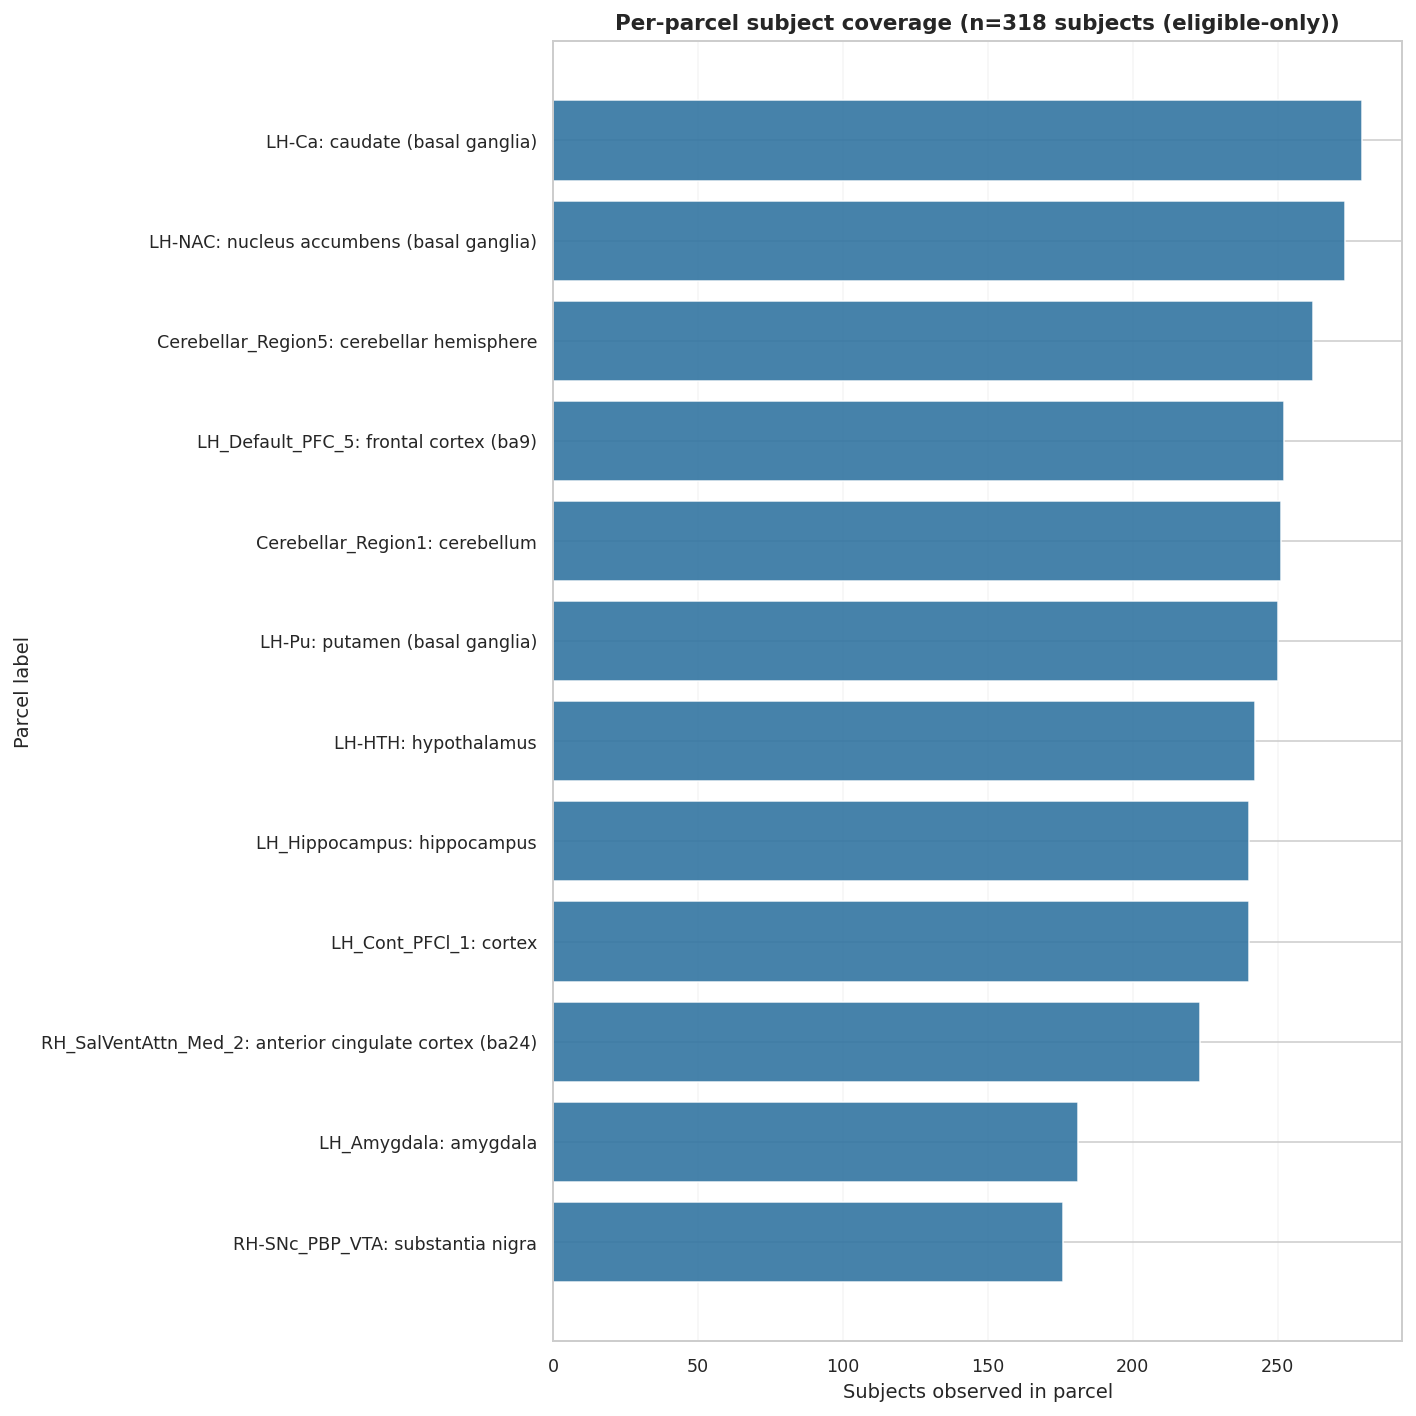

In [6]:
fig_h = max(8.0, 0.20 * len(count_df))
fig, ax = plot_parcel_subject_counts(count_df, top_n=None, min_subjects=1, figsize=(10, 10))


,n_regions_sampled,n_subjects,eligible_only,n_subjects_pool
0,5,21,True,318
1,6,29,True,318
2,7,36,True,318
3,8,29,True,318
4,9,53,True,318
5,10,54,True,318
6,11,63,True,318
7,12,33,True,318


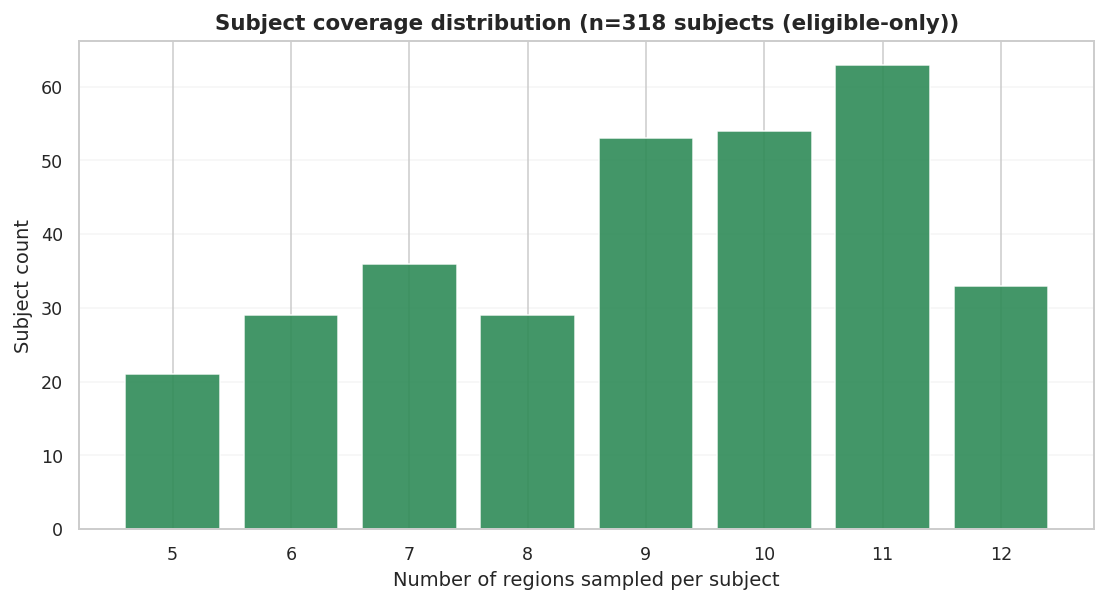

In [7]:
# LORO-relevant: x=regions sampled per subject, y=subject count
subj_cov = subject_region_count_distribution(PREPOST, eligible_only=ELIGIBLE_ONLY)
display(subj_cov)
fig, ax = plot_subject_region_count_distribution(subj_cov)


## 2) Pre/Post ComBat Diagnostics


In [8]:
# gene_mode: 'hvg' | 'allgenes' | 'custom'
GENE_MODE = 'hvg'
CUSTOM_GENE_LIST = None

atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 12
genes in panel: 88


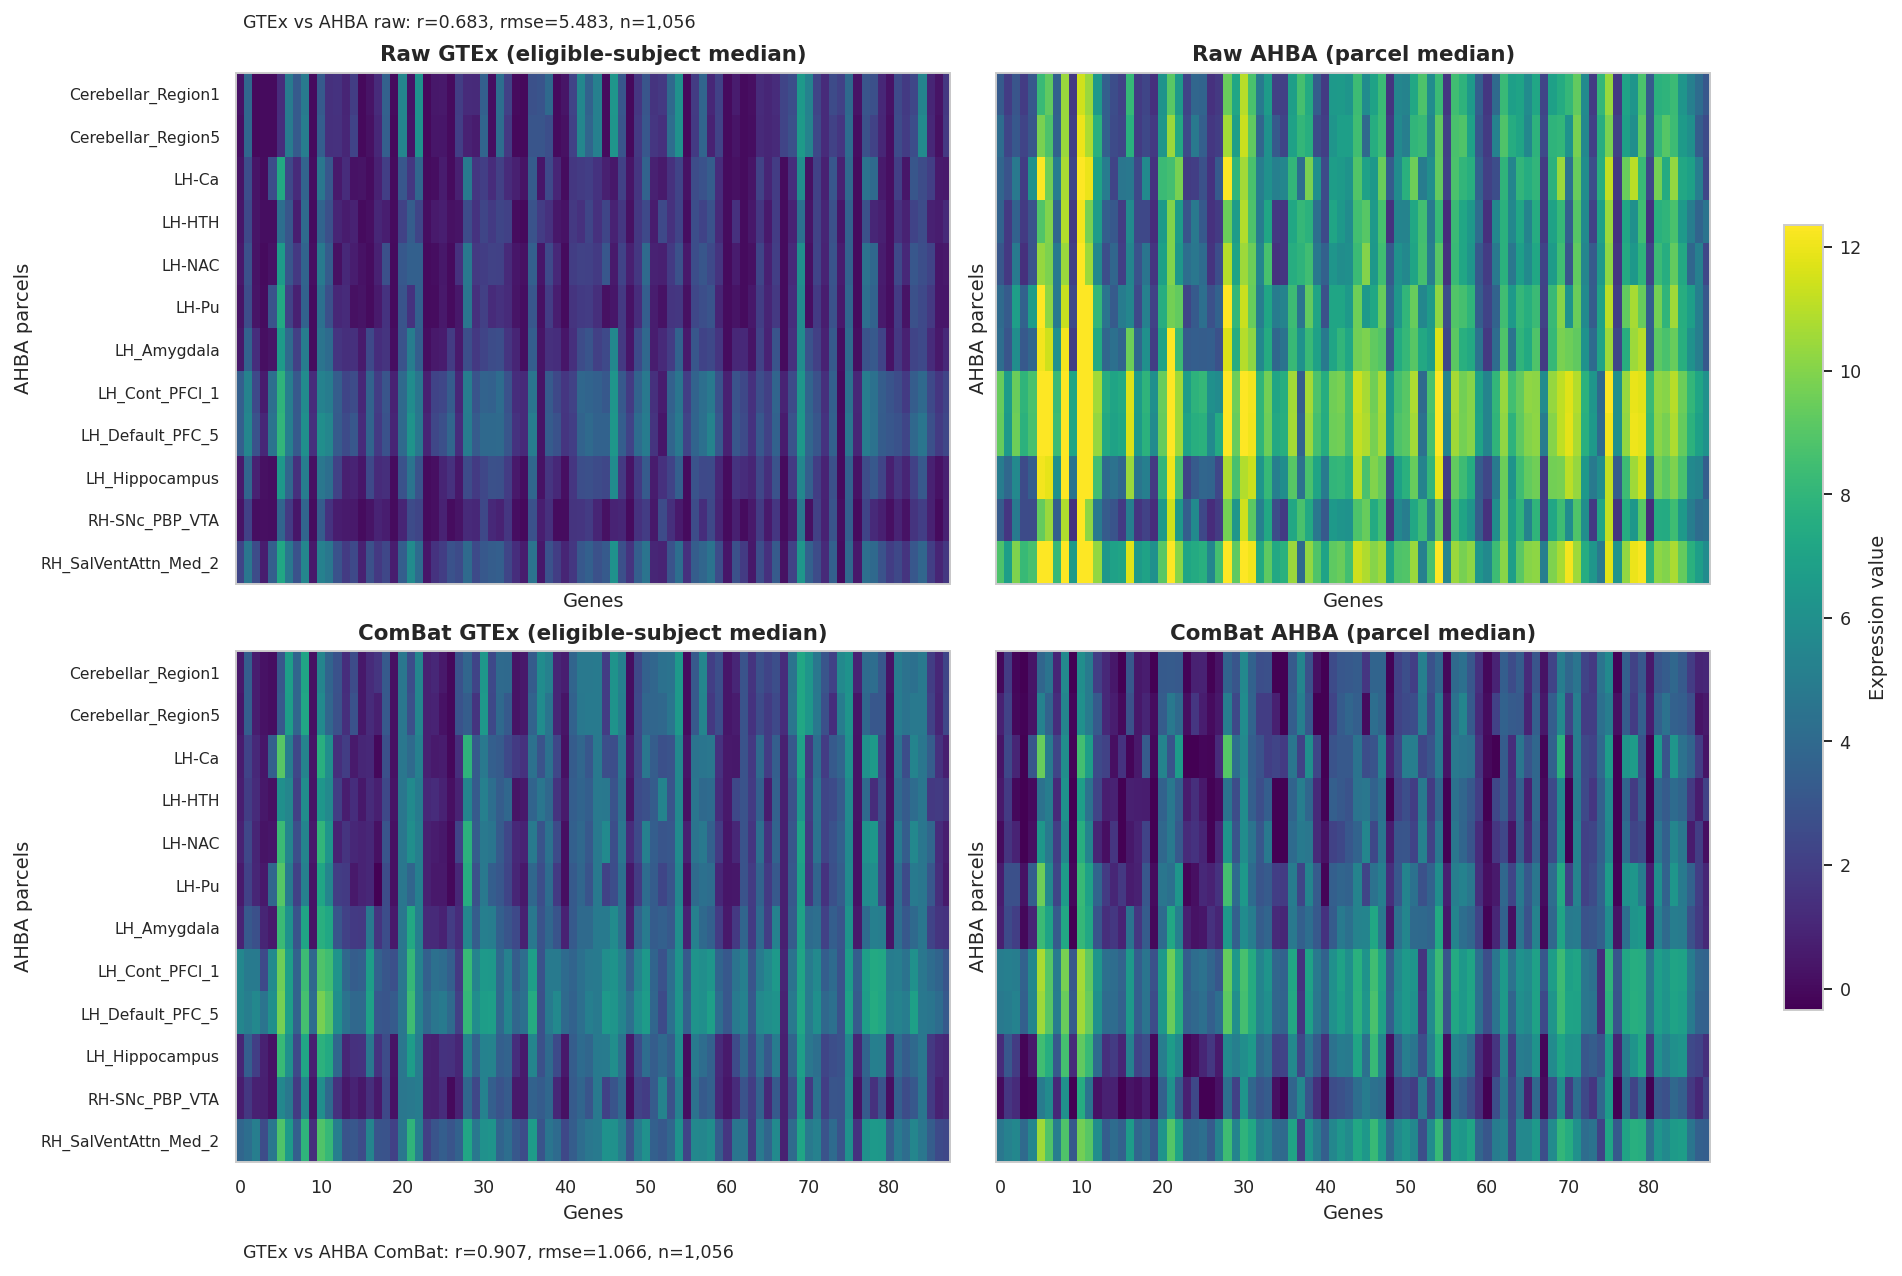

In [9]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


subject: GTEX-1117F


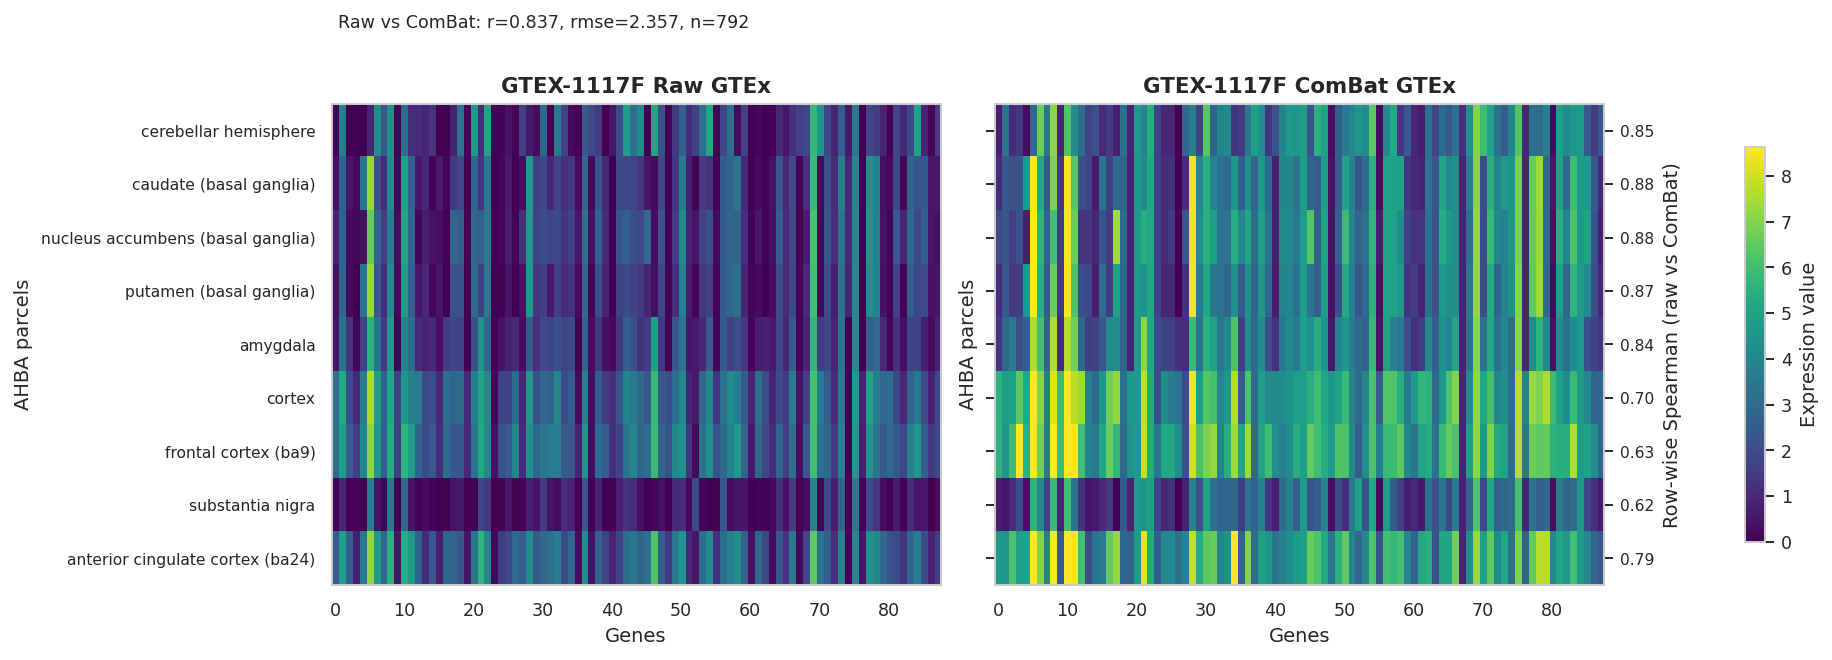

In [10]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


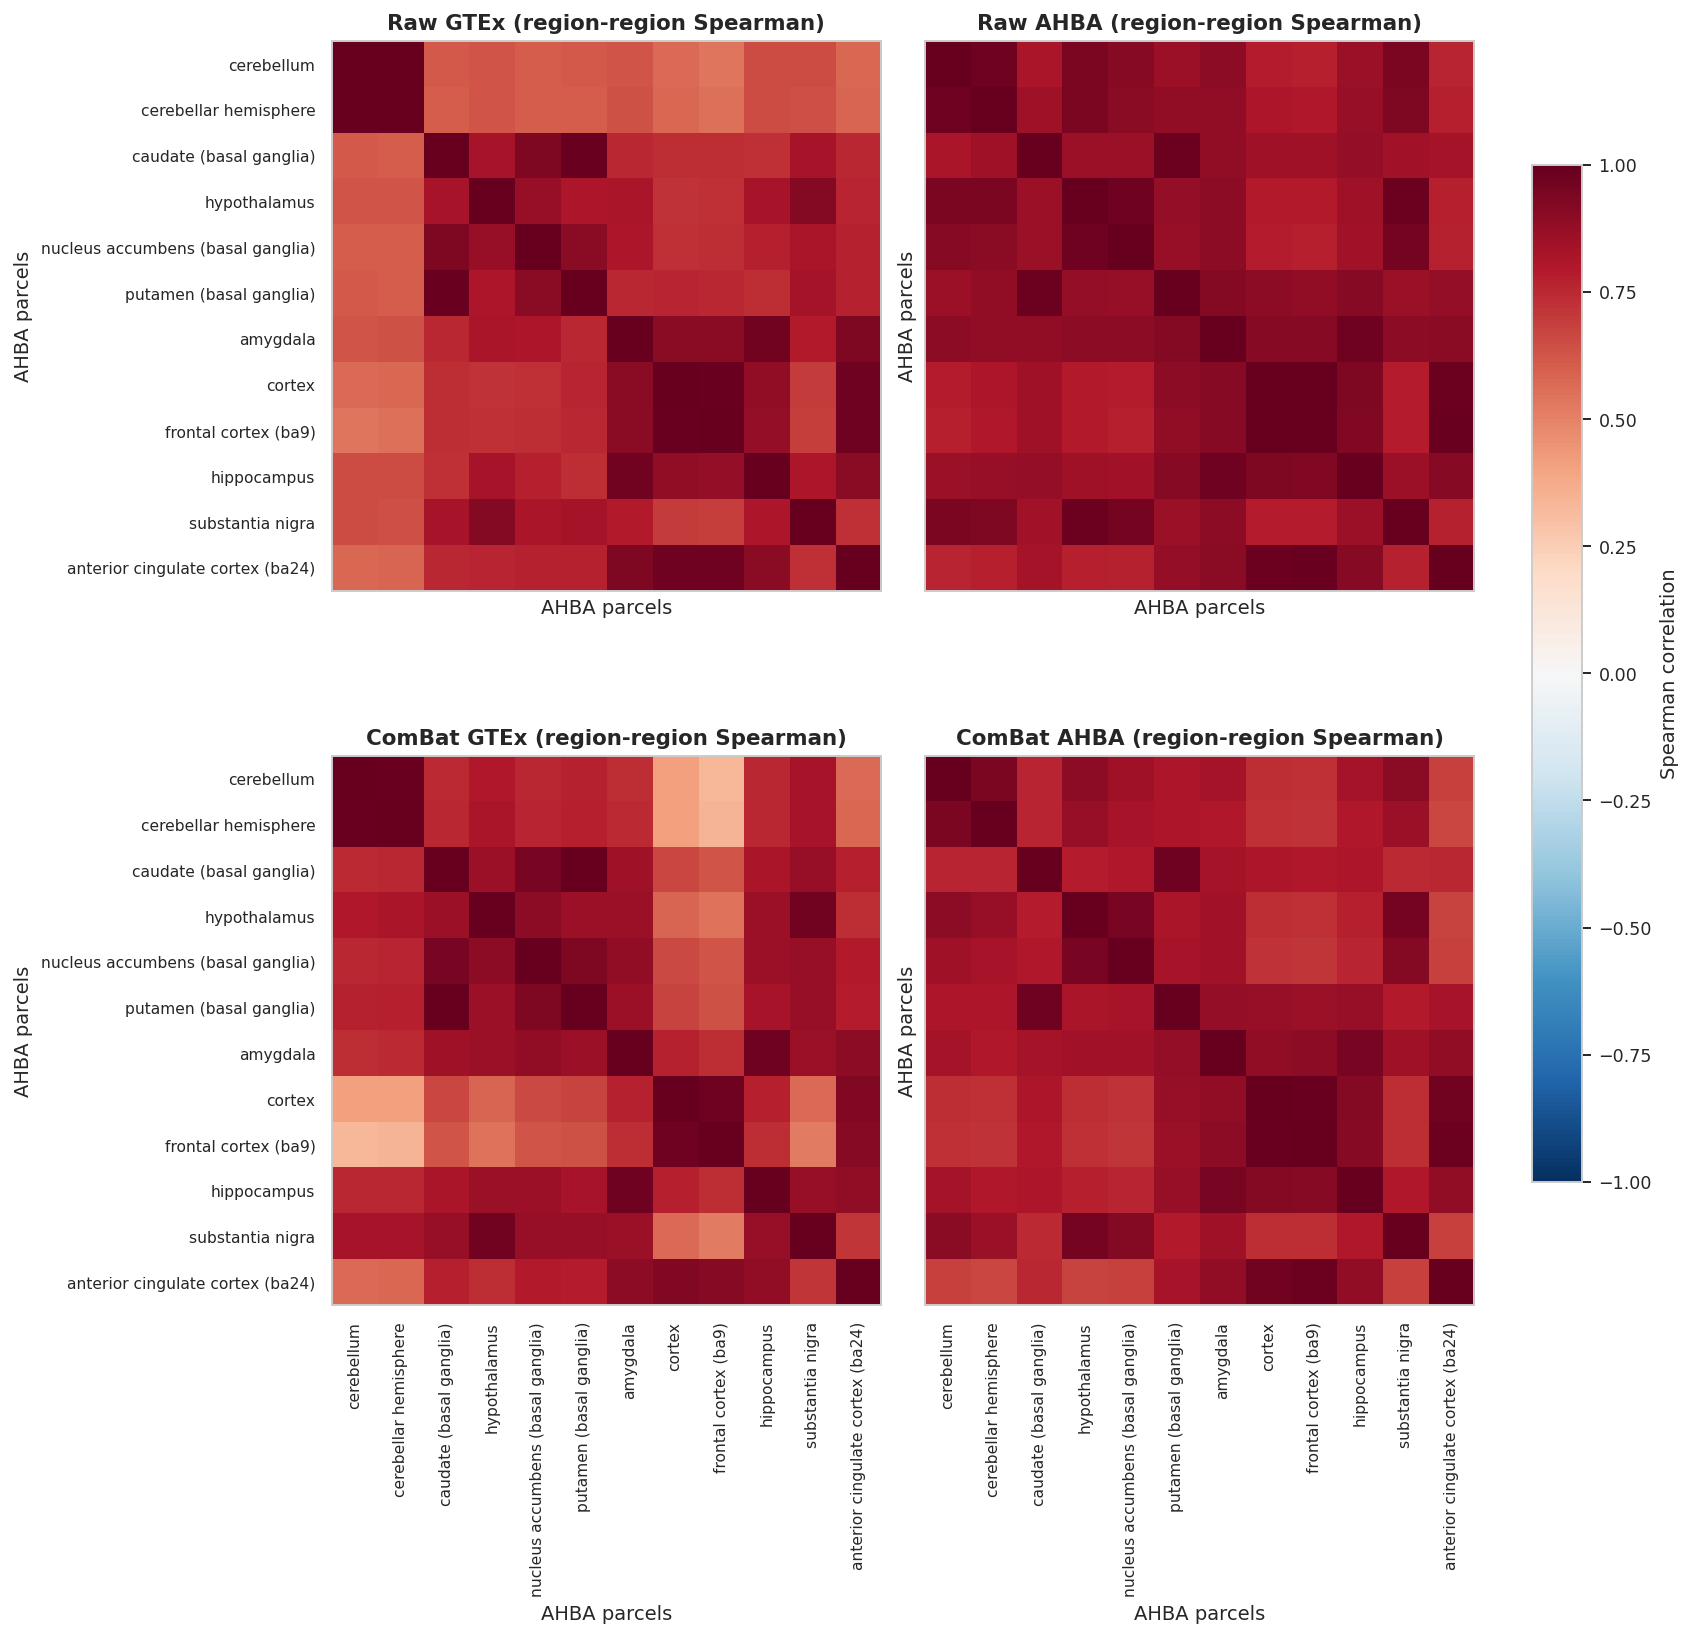

In [11]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


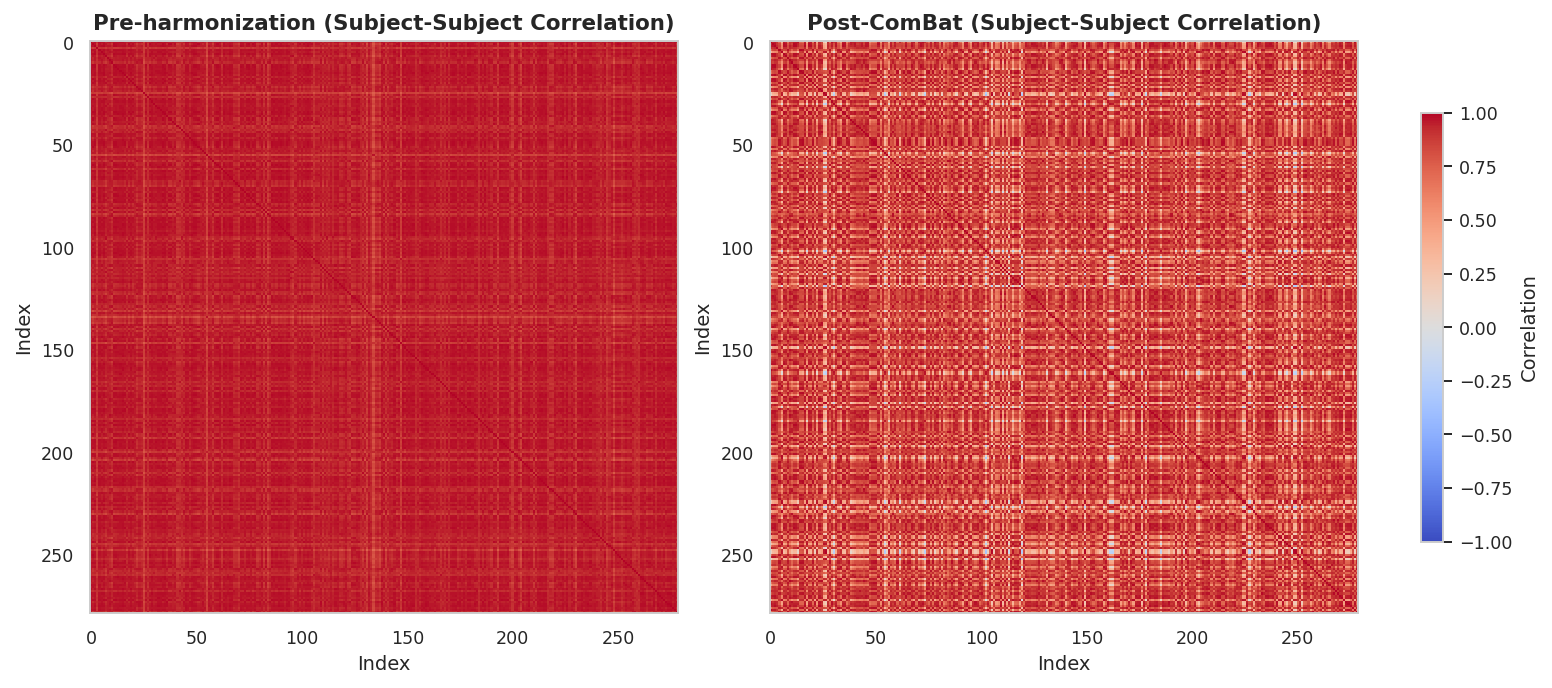

In [12]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')


## 3) Performance across Gene Panels


In [13]:
import src.eval_utils.results_eda as results_eda
importlib.reload(results_eda)

import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *


In [14]:
import importlib
import src.eval_utils.results_eda as results_eda
importlib.reload(results_eda)
from src.eval_utils.results_eda import *

from scipy.stats import ttest_rel
from itertools import combinations

MODELS = ['naive', 'dlam', 'plam']
N_JOBS = 16
RAW_MIXED_MODE = 'harmonized_pred_vs_raw_truth_corr'
REFZ_MIXED_MODE = 'harmonized_pred_vs_raw_truth_refz_corr'
REFZ_NOISE_QUANTILE = 0.20
DISABLE_RAW_BAR_METRICS = ['r2']


def paired_ttests_by_subject(metrics_df, label=''):
    pivot = metrics_df.pivot(index='subject', columns='model', values='pearson_r').dropna()
    model_names = pivot.columns.tolist()
    t_results = {}
    print(f"\nPaired t-tests for {label}:")
    for model1, model2 in combinations(model_names, 2):
        t_stat, p_val = ttest_rel(pivot[model1], pivot[model2])
        t_results[(model1, model2)] = {'t_stat': t_stat, 'p_val': p_val}
        print(f"  {model1} vs {model2}: t = {t_stat:.4f}, p = {p_val:.4g}")
    return pivot, t_results


def run_mixed_space_panel(label, mixed_space_mode, eval_gene_path=None):
    dfs = [
        compute_subject_metrics_from_cache_gene_subset(
            CFG,
            model=model,
            eval_gene_path=eval_gene_path,
            mixed_space_mode=mixed_space_mode,
            prepost=PREPOST,
            refz_noise_quantile=REFZ_NOISE_QUANTILE,
            n_jobs=N_JOBS,
        )
        for model in MODELS
    ]
    metrics_df = pd.concat(dfs, ignore_index=True)
    display(metrics_df.head())
    fig, axes, summary_df = plot_loro_subject_summary_bars(
        metrics_df,
        use_sem=True,
        disable_metrics=DISABLE_RAW_BAR_METRICS,
    )
    display(summary_df)
    pivot_df, t_results = paired_ttests_by_subject(metrics_df, label=label)
    display(pivot_df.head())
    return metrics_df, summary_df, pivot_df, t_results

Each gene panel is shown twice in sequence:
1. `harmonized_pred_vs_raw_truth_corr`
2. `harmonized_pred_vs_raw_truth_refz_corr` with `refz_noise_quantile=0.20`


### All gene performance



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_corr,68090,0.677270,0.653354,-4.444302,2.949025
1,GTEX-131XW,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_corr,68090,0.670704,0.650046,-7.309388,3.308224
2,GTEX-13NZA,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_corr,68090,0.619375,0.602921,-5.508310,3.148516
3,GTEX-1477Z,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_corr,68090,0.710895,0.686942,-7.072527,3.179125
4,GTEX-17MF6,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_corr,68090,0.656937,0.636919,-6.396529,3.241149


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.662850,0.028158,0.642951,0.028272,-3.473953,1.206535,2.786684,0.213909,313,0.001592,0.001598,0.068197,0.012091
1,dlam,0.666671,0.075908,0.687963,0.051208,-2.566427,1.189631,2.482056,0.327738,313,0.004291,0.002894,0.067242,0.018525
2,plam,0.681855,0.065485,0.678624,0.048569,-2.272171,0.925317,2.381177,0.217732,313,0.003701,0.002745,0.052302,0.012307



Paired t-tests for all genes | raw truth corr:
  dlam vs naive: t = 0.9259, p = 0.3552
  dlam vs plam: t = -10.2151, p = 2.535e-21
  naive vs plam: t = -5.6210, p = 4.213e-08


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.681970,0.684216,0.680051
GTEX-111FC,0.719227,0.677091,0.712692
GTEX-117XS,0.719700,0.685019,0.724851
GTEX-1192W,0.703019,0.677270,0.695544
GTEX-1192X,0.730012,0.688530,0.759174


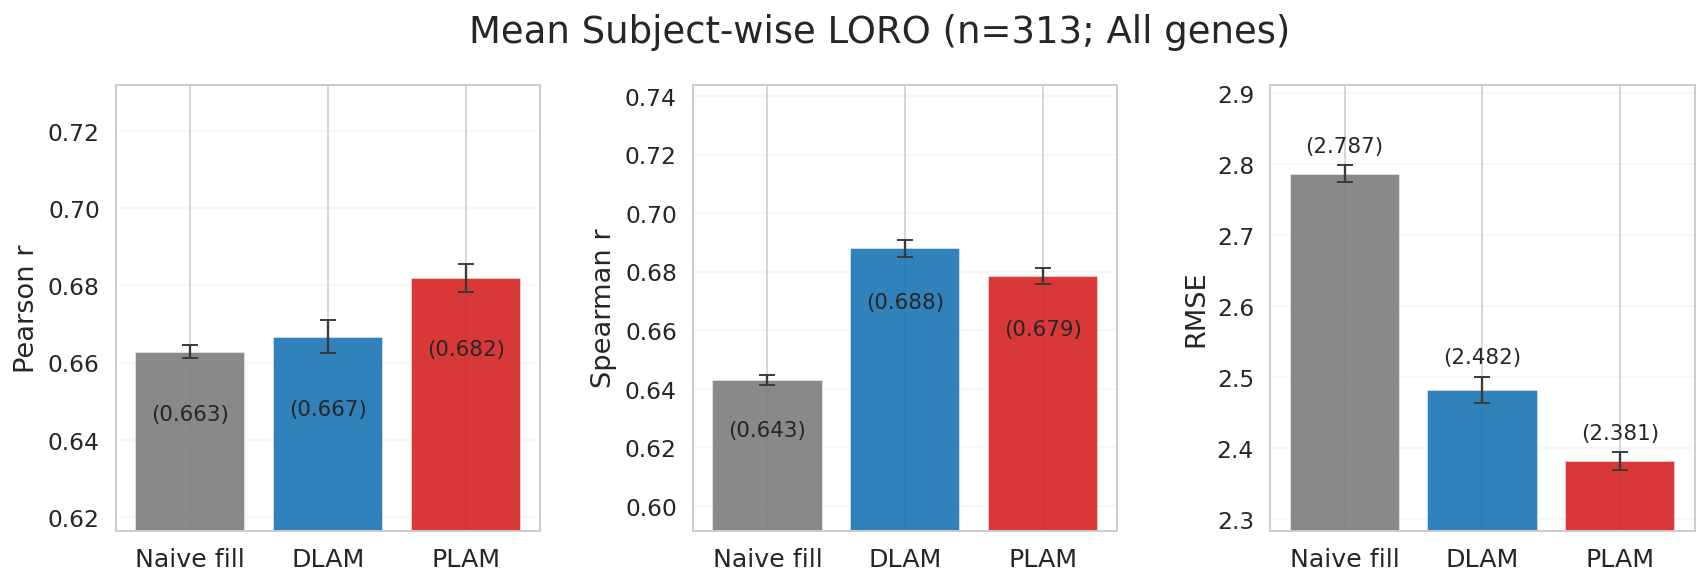

In [15]:
metrics_allgenes_raw, summary_allgenes_raw, pivot_allgenes_raw, t_results_allgenes_raw = run_mixed_space_panel(
    label='all genes | raw truth corr',
    mixed_space_mode=RAW_MIXED_MODE,
)

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_refz_corr,42260,-0.011044,0.036435,-8.401623,2.785051
1,GTEX-131XW,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_refz_corr,42260,0.021791,0.033539,-14.817084,3.385707
2,GTEX-13NZA,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_refz_corr,42260,-0.076413,-0.046513,-8.041680,3.214749
3,GTEX-1477Z,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_refz_corr,42260,0.071456,0.092142,-18.311235,3.062009
4,GTEX-17MF6,naive,5,5,13618,13618,all,None,harmonized_pred_vs_raw_truth_refz_corr,42260,-0.113092,-0.113575,-15.184565,3.324779


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.032416,0.059327,0.072995,0.069903,-8.387896,2.397559,2.741099,0.275420,313,0.003353,0.003951,0.135518,0.015568
1,dlam,0.078901,0.061058,0.089931,0.053063,-1.170829,1.061735,1.314557,0.305261,313,0.003451,0.002999,0.060013,0.017254
2,plam,0.022178,0.081514,0.054410,0.089243,-3.540718,1.292784,1.904875,0.220897,313,0.004607,0.005044,0.073072,0.012486



Paired t-tests for all genes | refz corr:
  dlam vs naive: t = 11.4790, p = 1.113e-25
  dlam vs plam: t = 13.2490, p = 4.296e-32
  naive vs plam: t = 3.5265, p = 0.0004842


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.111655,0.020387,0.053862
GTEX-111FC,0.061041,0.047884,0.011990
GTEX-117XS,0.041368,0.119997,0.095400
GTEX-1192W,0.069923,-0.011044,-0.039256
GTEX-1192X,0.119476,0.085598,0.077212


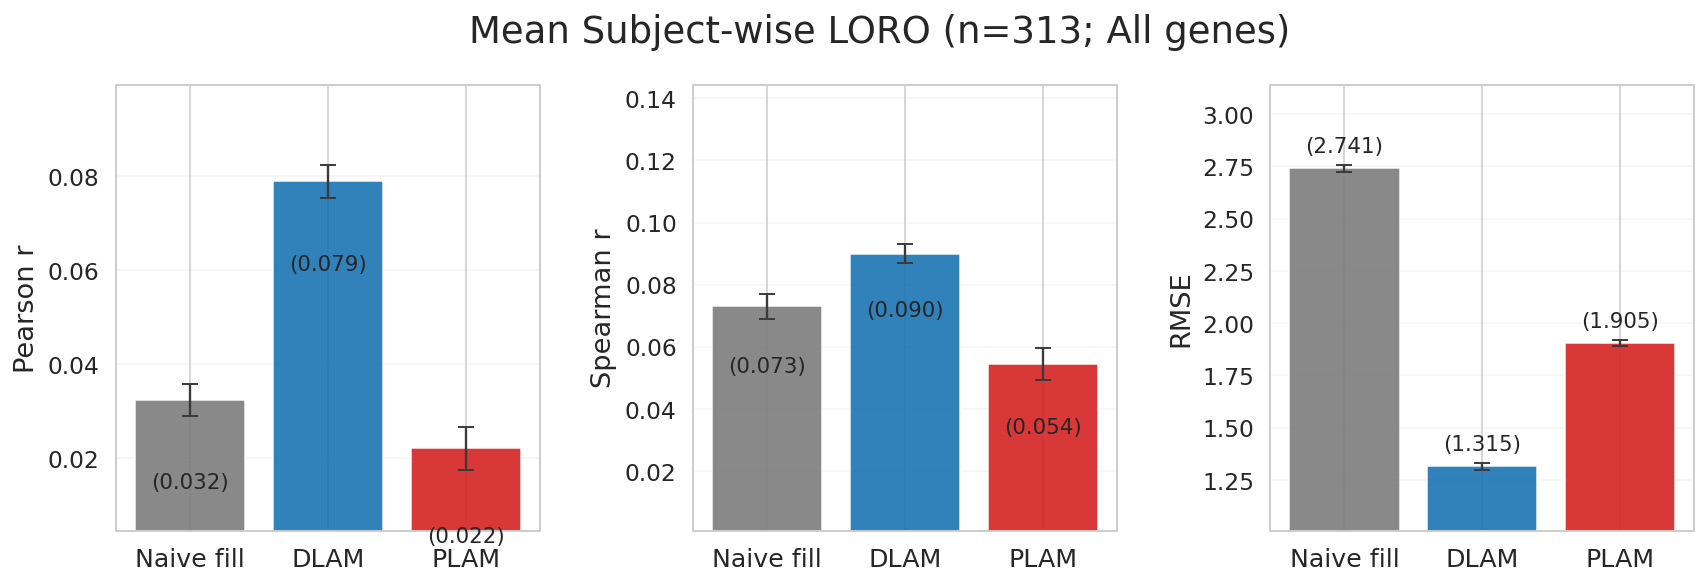

In [16]:
metrics_allgenes_refz, summary_allgenes_refz, pivot_allgenes_refz, t_results_allgenes_refz = run_mixed_space_panel(
    label='all genes | refz corr',
    mixed_space_mode=REFZ_MIXED_MODE,
)

### AHBA 100 HVG



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,440,0.731804,0.721612,-1.834627,2.655646
1,GTEX-131XW,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,440,0.740781,0.773257,-2.959830,2.842604
2,GTEX-13NZA,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,440,0.624986,0.680782,-2.905830,2.791996
3,GTEX-1477Z,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,440,0.718258,0.739252,-5.720364,3.143619
4,GTEX-17MF6,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,440,0.682043,0.730012,-4.560815,3.044810


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.740532,0.060237,0.757238,0.044002,-1.129519,1.200546,2.254258,0.321866,313,0.003405,0.002487,0.067859,0.018193
1,dlam,0.673693,0.083110,0.679559,0.090013,-0.825855,0.666807,2.143912,0.381535,313,0.004698,0.005088,0.037690,0.021566
2,plam,0.713129,0.067462,0.726695,0.053605,-0.625037,0.642699,2.006938,0.350125,313,0.003813,0.003030,0.036328,0.019790



Paired t-tests for ahba_100hvg | raw truth corr:
  dlam vs naive: t = -11.8465, p = 5.51e-27
  dlam vs plam: t = -7.5844, p = 3.865e-13
  naive vs plam: t = 13.6081, p = 1.99e-33


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.550385,0.778519,0.762801
GTEX-111FC,0.614380,0.809274,0.746112
GTEX-117XS,0.637320,0.791109,0.733130
GTEX-1192W,0.591760,0.731804,0.728678
GTEX-1192X,0.697623,0.781075,0.787315


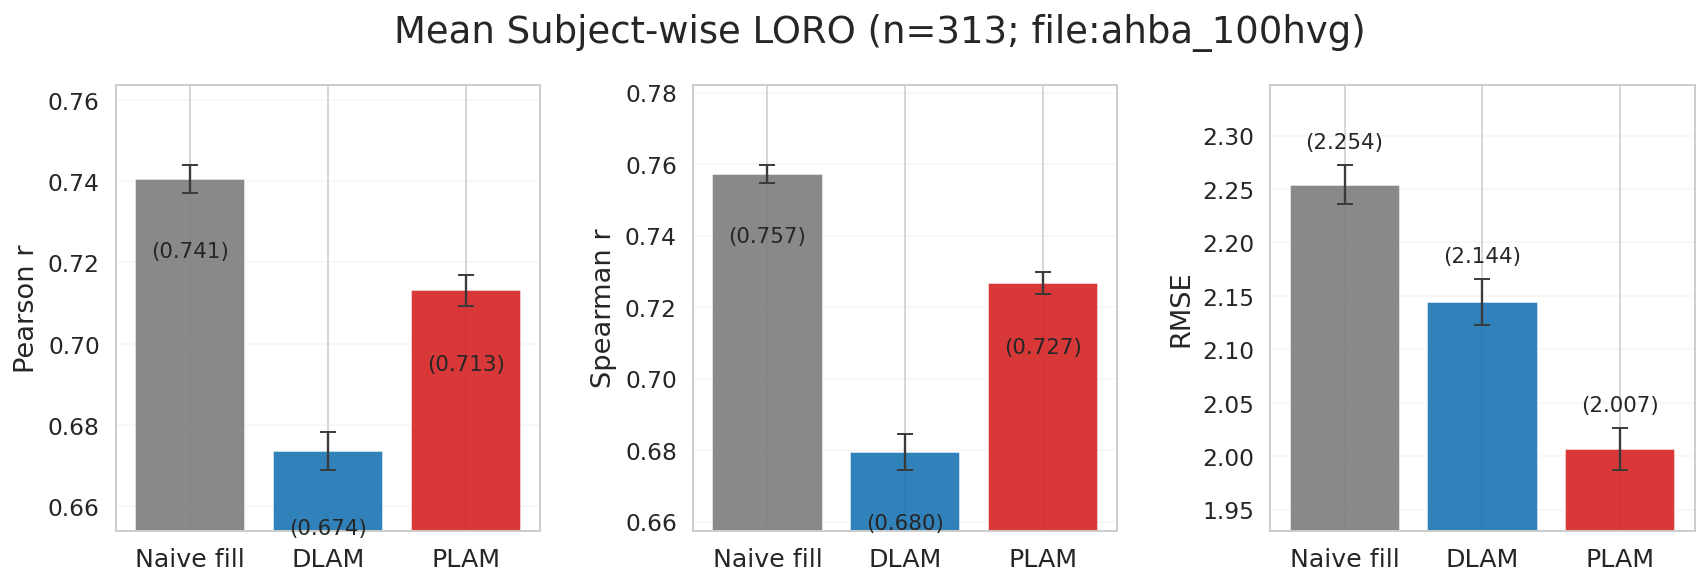

In [17]:
metrics_ahba100hvg_raw, summary_ahba100hvg_raw, pivot_ahba100hvg_raw, t_results_ahba100hvg_raw = run_mixed_space_panel(
    label='ahba_100hvg | raw truth corr',
    mixed_space_mode=RAW_MIXED_MODE,
    eval_gene_path='ahba_100hvg',
)

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,420,0.331010,0.518589,-2.637010,1.877443
1,GTEX-131XW,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,420,0.431423,0.597340,-4.607254,2.101990
2,GTEX-13NZA,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,420,0.143155,0.219161,-4.379385,1.966791
3,GTEX-1477Z,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,420,0.302055,0.405928,-12.417376,2.206376
4,GTEX-17MF6,naive,5,5,88,13618,file:ahba_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,420,0.071729,0.166428,-8.194190,2.059891


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.304030,0.117686,0.480130,0.139606,-3.067376,1.708966,1.816753,0.132824,313,0.006652,0.007891,0.096596,0.007508
1,dlam,0.398689,0.241599,0.368785,0.231534,-0.242717,0.706793,1.008807,0.283580,313,0.013656,0.013087,0.039950,0.016029
2,plam,0.252802,0.147903,0.443357,0.155568,-2.445308,1.257270,1.687026,0.218313,313,0.008360,0.008793,0.071065,0.012340



Paired t-tests for ahba_100hvg | refz corr:
  dlam vs naive: t = 5.9166, p = 8.642e-09
  dlam vs plam: t = 8.8188, p = 8.335e-17
  naive vs plam: t = 14.0412, p = 4.761e-35


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.107722,0.413775,0.465623
GTEX-111FC,0.352077,0.422992,0.430813
GTEX-117XS,0.335362,0.396329,0.358471
GTEX-1192W,0.345948,0.331010,0.366035
GTEX-1192X,0.367199,0.399750,0.358336


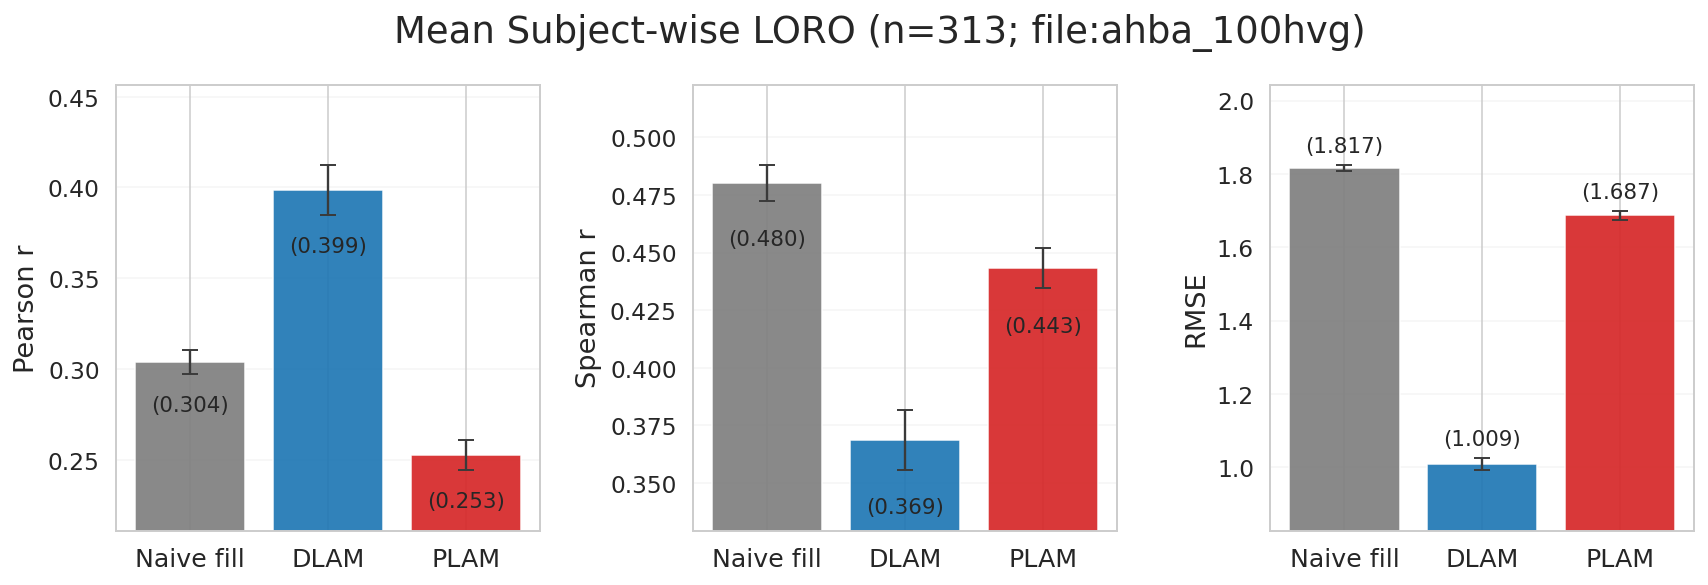

In [18]:
metrics_ahba100hvg_refz, summary_ahba100hvg_refz, pivot_ahba100hvg_refz, t_results_ahba100hvg_refz = run_mixed_space_panel(
    label='ahba_100hvg | refz corr',
    mixed_space_mode=REFZ_MIXED_MODE,
    eval_gene_path='ahba_100hvg',
)

### GTEx 100 HVG



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,500,0.474206,0.458737,-2.973715,3.369601
1,GTEX-131XW,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,500,0.508632,0.491546,-3.903066,3.464499
2,GTEX-13NZA,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,500,0.379105,0.407795,-3.329019,3.580130
3,GTEX-1477Z,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,500,0.572014,0.568100,-5.474252,3.657774
4,GTEX-17MF6,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,500,0.544085,0.573909,-4.697707,3.773383


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.513188,0.068148,0.506838,0.056331,-1.753735,1.233670,3.031868,0.315595,313,0.003852,0.003184,0.069731,0.017838
1,dlam,0.466636,0.071321,0.482821,0.069754,-1.148147,0.665184,2.710993,0.196996,313,0.004031,0.003943,0.037598,0.011135
2,plam,0.492819,0.068227,0.503484,0.057532,-1.042494,0.622489,2.644899,0.175520,313,0.003856,0.003252,0.035185,0.009921



Paired t-tests for gtex_100hvg | raw truth corr:
  dlam vs naive: t = -10.0192, p = 1.143e-20
  dlam vs plam: t = -5.8945, p = 9.747e-09
  naive vs plam: t = 9.3625, p = 1.6e-18


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.417646,0.569463,0.564660
GTEX-111FC,0.528813,0.540466,0.576258
GTEX-117XS,0.458710,0.570819,0.538416
GTEX-1192W,0.402100,0.474206,0.517459
GTEX-1192X,0.474681,0.556048,0.531552


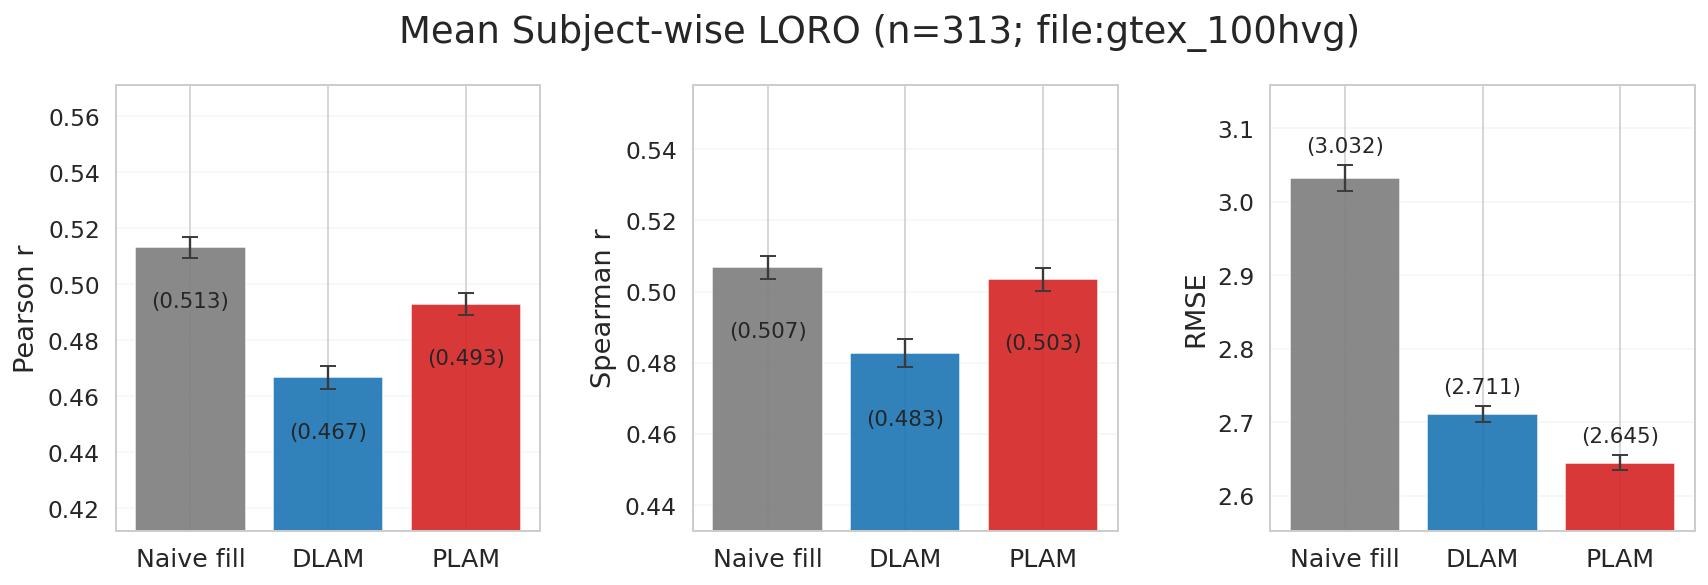

In [19]:
metrics_gtex100hvg_raw, summary_gtex100hvg_raw, pivot_gtex100hvg_raw, t_results_gtex100hvg_raw = run_mixed_space_panel(
    label='gtex_100hvg | raw truth corr',
    mixed_space_mode=RAW_MIXED_MODE,
    eval_gene_path='gtex_100hvg',
)

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,440,0.215813,0.324841,-9.128336,2.731441
1,GTEX-131XW,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,440,0.248832,0.436614,-11.328454,2.888489
2,GTEX-13NZA,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,440,0.128995,0.290651,-7.747676,2.813000
3,GTEX-1477Z,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,440,0.229497,0.397563,-16.652638,2.822989
4,GTEX-17MF6,naive,5,5,100,13618,file:gtex_100hvg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,440,0.169526,0.378804,-13.525038,2.827991


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.230125,0.042849,0.408137,0.049409,-6.789958,2.347725,2.660164,0.133087,313,0.002422,0.002793,0.132701,0.007523
1,dlam,0.381427,0.168361,0.376099,0.160998,-0.105496,0.299001,1.006941,0.109302,313,0.009516,0.009100,0.016901,0.006178
2,plam,0.196689,0.072230,0.389909,0.061019,-3.484782,0.908237,2.040680,0.194329,313,0.004083,0.003449,0.051337,0.010984



Paired t-tests for gtex_100hvg | refz corr:
  dlam vs naive: t = 15.2015, p = 1.935e-39
  dlam vs plam: t = 16.7277, p = 2.771e-45
  naive vs plam: t = 10.7050, p = 5.516e-23


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.135076,0.257083,0.304626
GTEX-111FC,0.433165,0.257174,0.270535
GTEX-117XS,0.389400,0.263738,0.237072
GTEX-1192W,0.221103,0.215813,0.220514
GTEX-1192X,0.411880,0.254537,0.227123


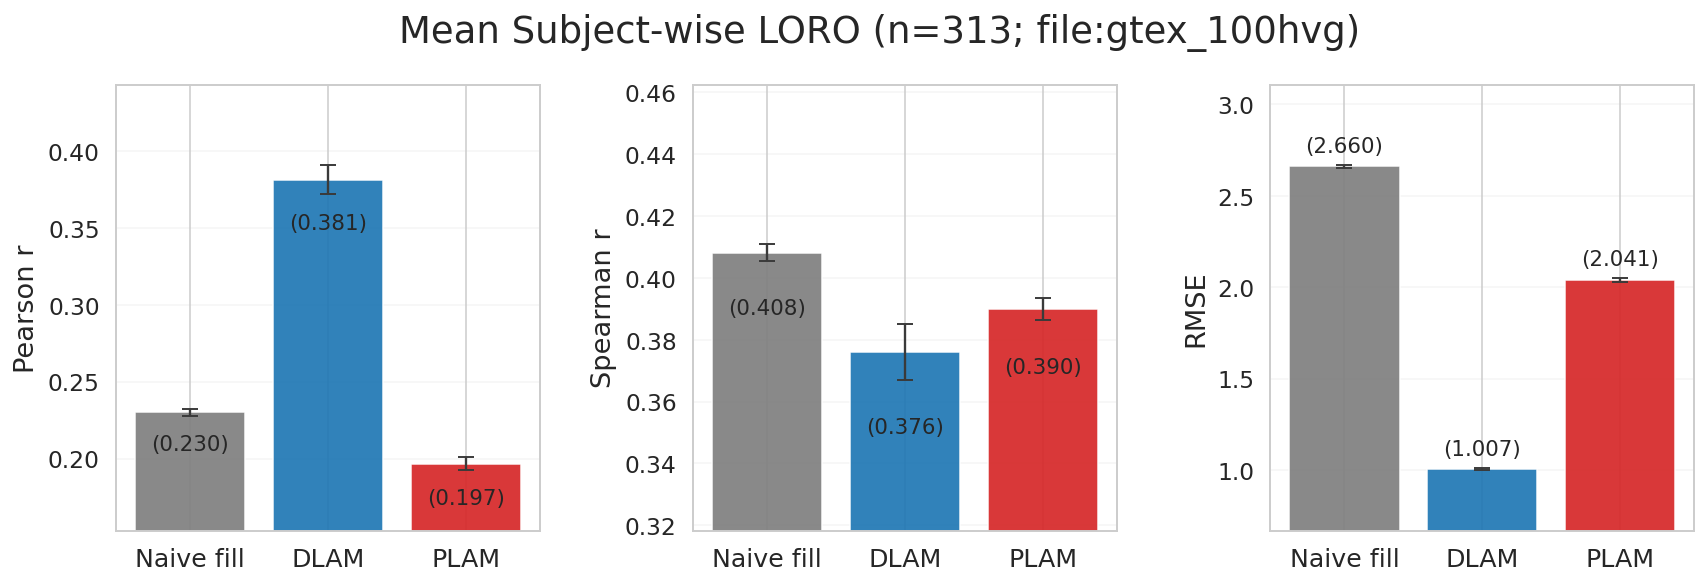

In [20]:
metrics_gtex100hvg_refz, summary_gtex100hvg_refz, pivot_gtex100hvg_refz, t_results_gtex100hvg_refz = run_mixed_space_panel(
    label='gtex_100hvg | refz corr',
    mixed_space_mode=REFZ_MIXED_MODE,
    eval_gene_path='gtex_100hvg',
)

### GTEx 120 DEG



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,845,0.533552,0.539585,-2.577394,3.269464
1,GTEX-131XW,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,845,0.571844,0.565583,-3.808891,3.426597
2,GTEX-13NZA,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,845,0.518966,0.544641,-3.048487,3.404064
3,GTEX-1477Z,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,845,0.643418,0.661536,-3.719449,3.359668
4,GTEX-17MF6,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,845,0.618866,0.657262,-2.656379,3.365989


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.599199,0.046019,0.596528,0.041311,-1.626508,0.836867,2.968155,0.267787,313,0.002601,0.002335,0.047303,0.015136
1,dlam,0.563325,0.059513,0.565286,0.061901,-1.053504,0.442614,2.647313,0.188242,313,0.003364,0.003499,0.025018,0.010640
2,plam,0.603186,0.042090,0.601727,0.039384,-0.921515,0.425644,2.558580,0.170461,313,0.002379,0.002226,0.024059,0.009635



Paired t-tests for gtex_25deg | raw truth corr:
  dlam vs naive: t = -10.0591, p = 8.424e-21
  dlam vs plam: t = -12.3164, p = 1.123e-28
  naive vs plam: t = -2.1113, p = 0.03554


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.532297,0.610417,0.646582
GTEX-111FC,0.568306,0.611944,0.629790
GTEX-117XS,0.544401,0.629449,0.625621
GTEX-1192W,0.499976,0.533552,0.571156
GTEX-1192X,0.568449,0.608041,0.633218


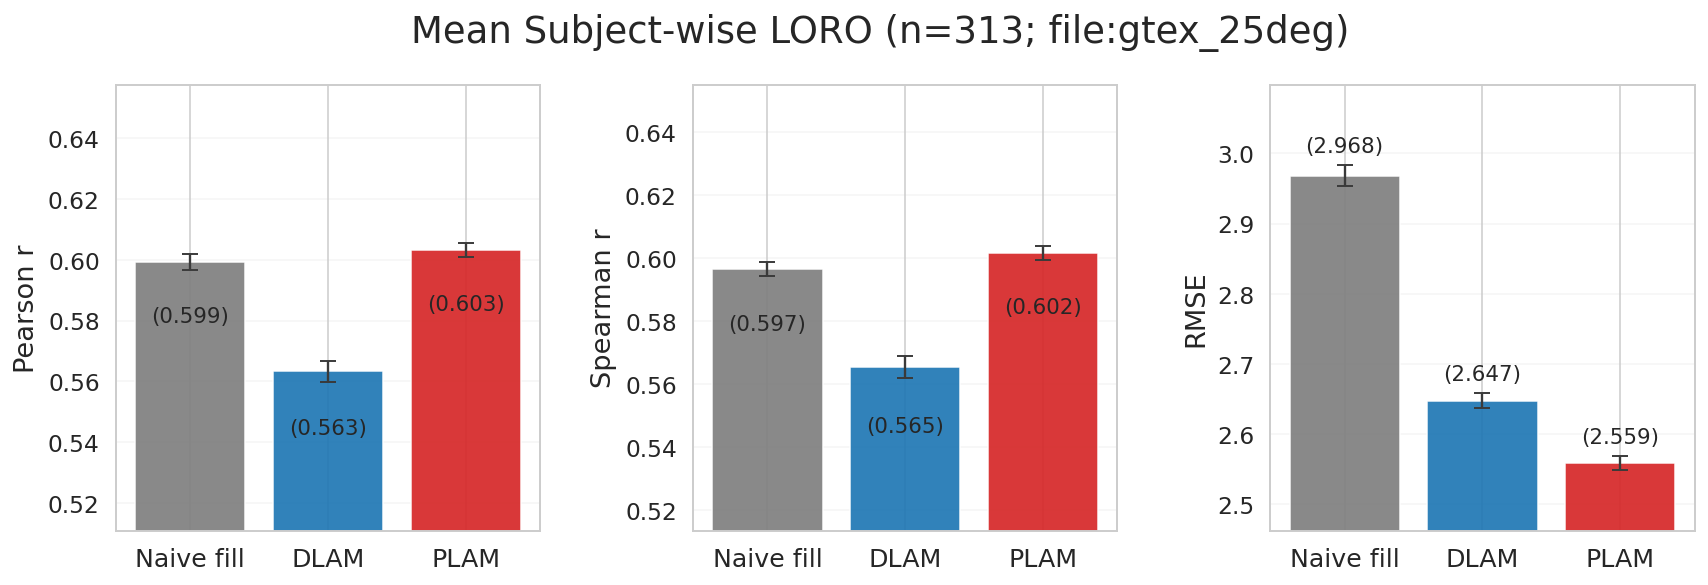

In [21]:
metrics_gtex25deg_raw, summary_gtex25deg_raw, pivot_gtex25deg_raw, t_results_gtex25deg_raw = run_mixed_space_panel(
    label='gtex_25deg | raw truth corr',
    mixed_space_mode=RAW_MIXED_MODE,
    eval_gene_path='gtex_25deg',
)

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,785,0.112304,0.248890,-6.820669,2.497224
1,GTEX-131XW,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,785,0.190903,0.397807,-8.120097,2.575461
2,GTEX-13NZA,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,785,0.120096,0.295613,-6.415709,2.669543
3,GTEX-1477Z,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,785,0.319349,0.488166,-7.792485,2.271101
4,GTEX-17MF6,naive,5,5,169,13618,file:gtex_25deg,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,785,0.196350,0.428973,-7.992573,2.493781


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.224034,0.049957,0.394264,0.057241,-5.976604,1.438945,2.528811,0.148706,313,0.002824,0.003235,0.081334,0.008405
1,dlam,0.288430,0.148149,0.290892,0.145795,-0.253795,0.302001,1.075587,0.142919,313,0.008374,0.008241,0.017070,0.008078
2,plam,0.193960,0.056337,0.337221,0.055871,-2.645400,0.643372,1.833715,0.127893,313,0.003184,0.003158,0.036366,0.007229



Paired t-tests for gtex_25deg | refz corr:
  dlam vs naive: t = 7.0756, p = 9.849e-12
  dlam vs plam: t = 10.3347, p = 1.003e-21
  naive vs plam: t = 11.0065, p = 5.028e-24


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.119392,0.204046,0.264869
GTEX-111FC,0.303492,0.233148,0.251008
GTEX-117XS,0.236065,0.277897,0.239009
GTEX-1192W,0.243801,0.112304,0.118590
GTEX-1192X,0.278696,0.227565,0.213105


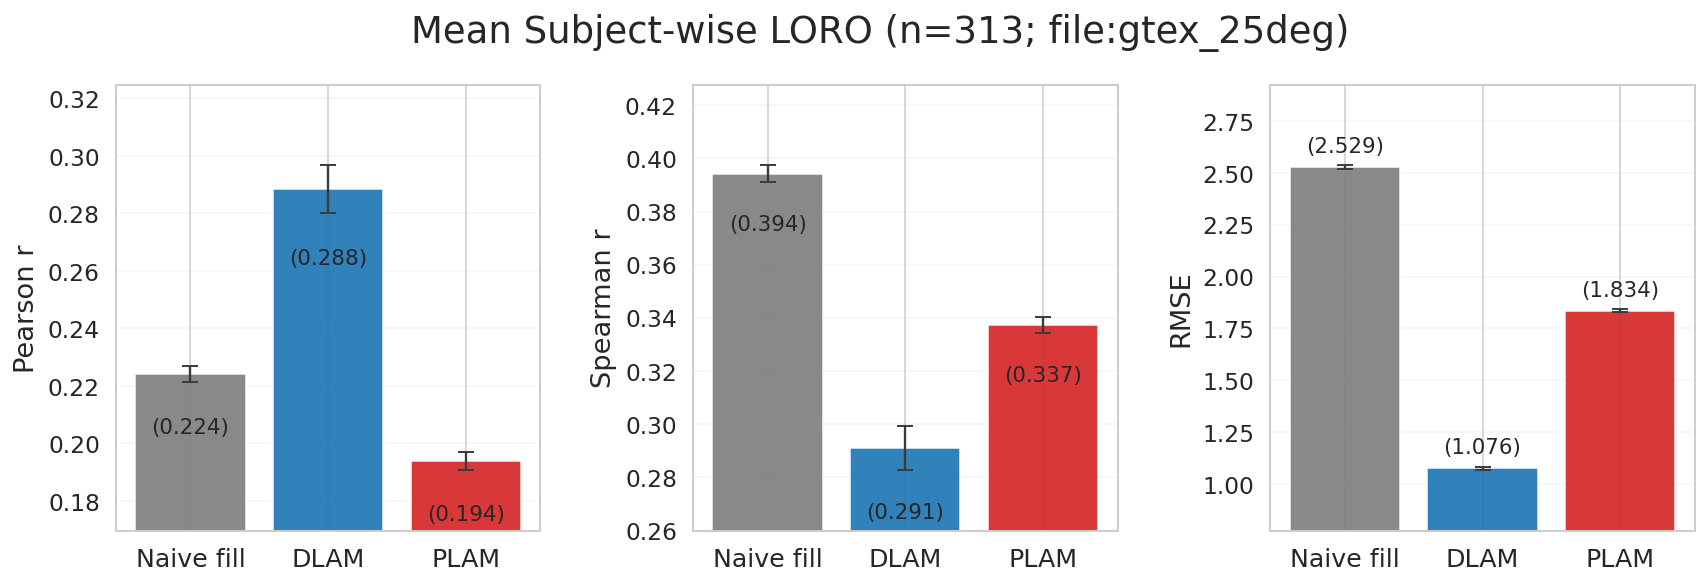

In [22]:
metrics_gtex25deg_refz, summary_gtex25deg_refz, pivot_gtex25deg_refz, t_results_gtex25deg_refz = run_mixed_space_panel(
    label='gtex_25deg | refz corr',
    mixed_space_mode=REFZ_MIXED_MODE,
    eval_gene_path='gtex_25deg',
)

### Richiardi 2015 gene list
Correlated gene expression supports synchronous activity in brain networks (Science, 2015)



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,515,0.640647,0.627610,-3.664744,2.796027
1,GTEX-131XW,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,515,0.664676,0.668470,-5.613239,3.015963
2,GTEX-13NZA,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,515,0.626562,0.648363,-3.987374,2.885371
3,GTEX-1477Z,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,515,0.675744,0.696431,-5.200788,2.945104
4,GTEX-17MF6,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,515,0.651352,0.682313,-4.853289,2.962152


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.681242,0.048390,0.671970,0.039238,-2.110438,1.321490,2.535497,0.234210,313,0.002735,0.002218,0.074695,0.013238
1,dlam,0.657396,0.064887,0.666829,0.055154,-1.589829,0.750821,2.349673,0.207942,313,0.003668,0.003117,0.042439,0.011754
2,plam,0.668842,0.051645,0.666258,0.036636,-1.411763,0.704426,2.263577,0.149822,313,0.002919,0.002071,0.039816,0.008468



Paired t-tests for richiardi2015 | raw truth corr:
  dlam vs naive: t = -6.3196, p = 9.046e-10
  dlam vs plam: t = -5.2193, p = 3.284e-07
  naive vs plam: t = 5.0525, p = 7.438e-07


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.646749,0.683649,0.690690
GTEX-111FC,0.689788,0.715105,0.710966
GTEX-117XS,0.709178,0.726111,0.726995
GTEX-1192W,0.626257,0.640647,0.647902
GTEX-1192X,0.688869,0.707429,0.704286


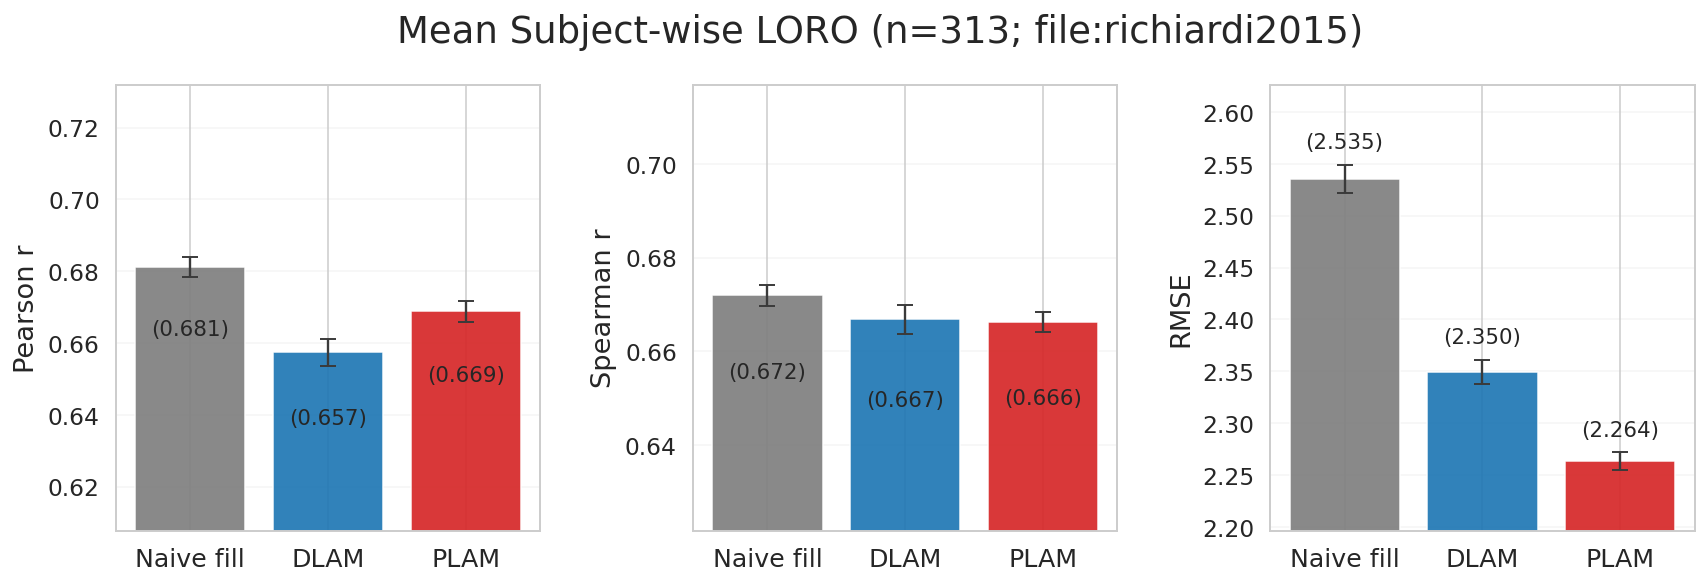

In [23]:
metrics_richiardi_raw, summary_richiardi_raw, pivot_richiardi_raw, t_results_richiardi_raw = run_mixed_space_panel(
    label='richiardi2015 | raw truth corr',
    mixed_space_mode=RAW_MIXED_MODE,
    eval_gene_path='richiardi2015',
)

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,405,0.183705,0.196147,-5.729137,2.168008
1,GTEX-131XW,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,405,0.200114,0.284892,-9.101312,2.496247
2,GTEX-13NZA,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,405,0.154169,0.257928,-4.361635,2.307237
3,GTEX-1477Z,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,405,0.227949,0.310731,-8.582636,2.358624
4,GTEX-17MF6,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,405,0.175224,0.212614,-7.940792,2.416560


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.214108,0.060036,0.308392,0.071996,-4.546446,1.261982,2.214749,0.138100,313,0.003393,0.004069,0.071331,0.007806
1,dlam,0.296189,0.150713,0.295104,0.140477,-0.346881,0.478561,1.089542,0.188062,313,0.008519,0.007940,0.027050,0.010630
2,plam,0.147720,0.057842,0.205357,0.059644,-2.242647,0.615864,1.700433,0.135112,313,0.003269,0.003371,0.034811,0.007637



Paired t-tests for richiardi2015 | refz corr:
  dlam vs naive: t = 8.6808, p = 2.224e-16
  dlam vs plam: t = 15.8649, p = 5.662e-42
  naive vs plam: t = 17.7086, p = 4.673e-49


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.085342,0.201039,0.206854
GTEX-111FC,0.251150,0.244150,0.189078
GTEX-117XS,0.279550,0.278890,0.191145
GTEX-1192W,0.219092,0.183705,0.076893
GTEX-1192X,0.352107,0.231789,0.153777


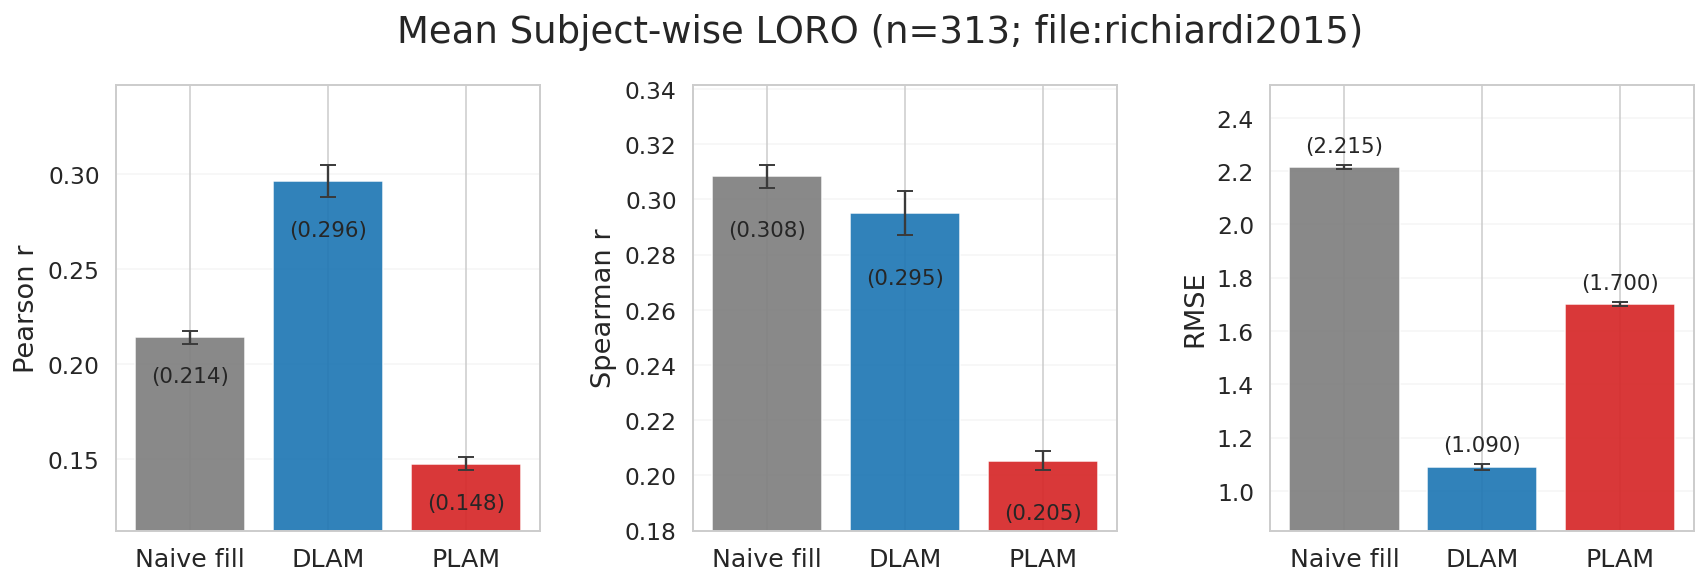

In [24]:
metrics_richiardi_refz, summary_richiardi_refz, pivot_richiardi_refz, t_results_richiardi_refz = run_mixed_space_panel(
    label='richiardi2015 | refz corr',
    mixed_space_mode=REFZ_MIXED_MODE,
    eval_gene_path='richiardi2015',
)

### Synaptic gene ontology list



,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,7130,0.677750,0.639592,-3.514523,3.177848
1,GTEX-131XW,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,7130,0.684058,0.648293,-5.643923,3.542884
2,GTEX-13NZA,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,7130,0.607626,0.570791,-4.525795,3.426534
3,GTEX-1477Z,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,7130,0.709848,0.663923,-5.839922,3.498018
4,GTEX-17MF6,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_corr,7130,0.651353,0.607622,-5.134433,3.600773


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.675518,0.028970,0.642458,0.030675,-2.788596,0.948050,2.913628,0.288256,313,0.001638,0.001734,0.053587,0.016293
1,dlam,0.713103,0.041599,0.696349,0.038564,-1.656578,0.644408,2.440310,0.240905,313,0.002351,0.002180,0.036424,0.013617
2,plam,0.711329,0.038226,0.687786,0.038574,-1.632999,0.664432,2.427866,0.252007,313,0.002161,0.002180,0.037556,0.014244



Paired t-tests for syngo | raw truth corr:
  dlam vs naive: t = 16.6926, p = 3.779e-45
  dlam vs plam: t = 1.5931, p = 0.1121
  naive vs plam: t = -21.7054, p = 2.597e-64


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.723099,0.704772,0.738140
GTEX-111FC,0.715249,0.696131,0.714398
GTEX-117XS,0.722895,0.697205,0.727009
GTEX-1192W,0.700076,0.677750,0.705447
GTEX-1192X,0.765912,0.704342,0.767759


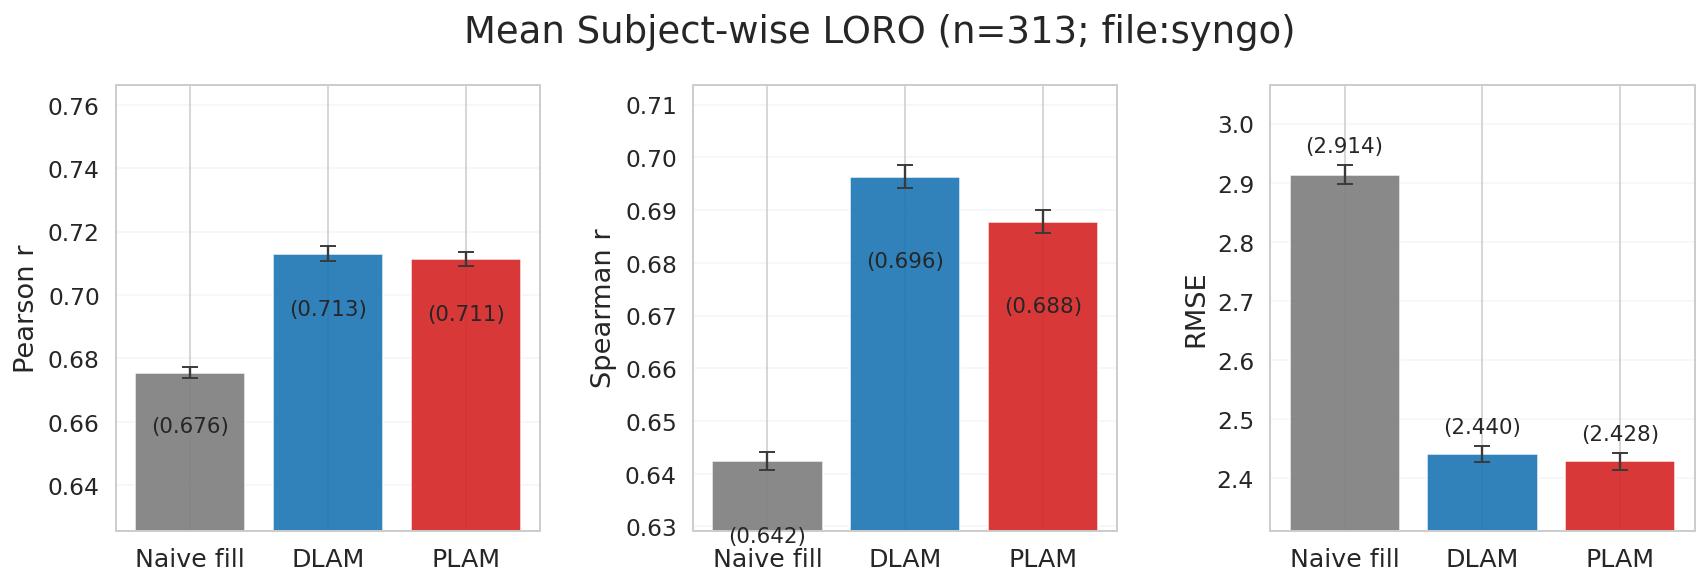

In [25]:
metrics_syngo_raw, summary_syngo_raw, pivot_syngo_raw, t_results_syngo_raw = run_mixed_space_panel(
    label='syngo | raw truth corr',
    mixed_space_mode=RAW_MIXED_MODE,
    eval_gene_path='syngo',
)

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,mixed_space_mode,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,5280,0.051933,0.123279,-7.905815,2.963461
1,GTEX-131XW,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,5280,0.110337,0.132491,-12.742425,3.390681
2,GTEX-13NZA,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,5280,-0.084318,-0.051984,-9.345496,3.455719
3,GTEX-1477Z,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,5280,0.117398,0.137957,-20.339959,3.191471
4,GTEX-17MF6,naive,5,5,1426,13618,file:syngo,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,harmonized_pred_vs_raw_truth_refz_corr,5280,-0.082072,-0.078106,-18.391458,3.601828


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.066164,0.065235,0.122415,0.073159,-9.159092,2.498892,2.820420,0.274049,313,0.003687,0.004135,0.141246,0.015490
1,dlam,0.104957,0.073242,0.122798,0.072601,-1.116173,1.023598,1.282112,0.292270,313,0.004140,0.004104,0.057857,0.016520
2,plam,0.052065,0.090245,0.102094,0.098389,-3.985702,1.335999,1.973976,0.218327,313,0.005101,0.005561,0.075515,0.012341



Paired t-tests for syngo | refz corr:
  dlam vs naive: t = 8.0270, p = 2.052e-14
  dlam vs plam: t = 9.7683, p = 7.707e-20
  naive vs plam: t = 4.8178, p = 2.269e-06


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.078305,0.103707,0.146606
GTEX-111FC,0.101150,0.112827,0.089583
GTEX-117XS,0.089512,0.131733,0.121496
GTEX-1192W,0.094671,0.051933,0.053820
GTEX-1192X,0.143415,0.131619,0.112452


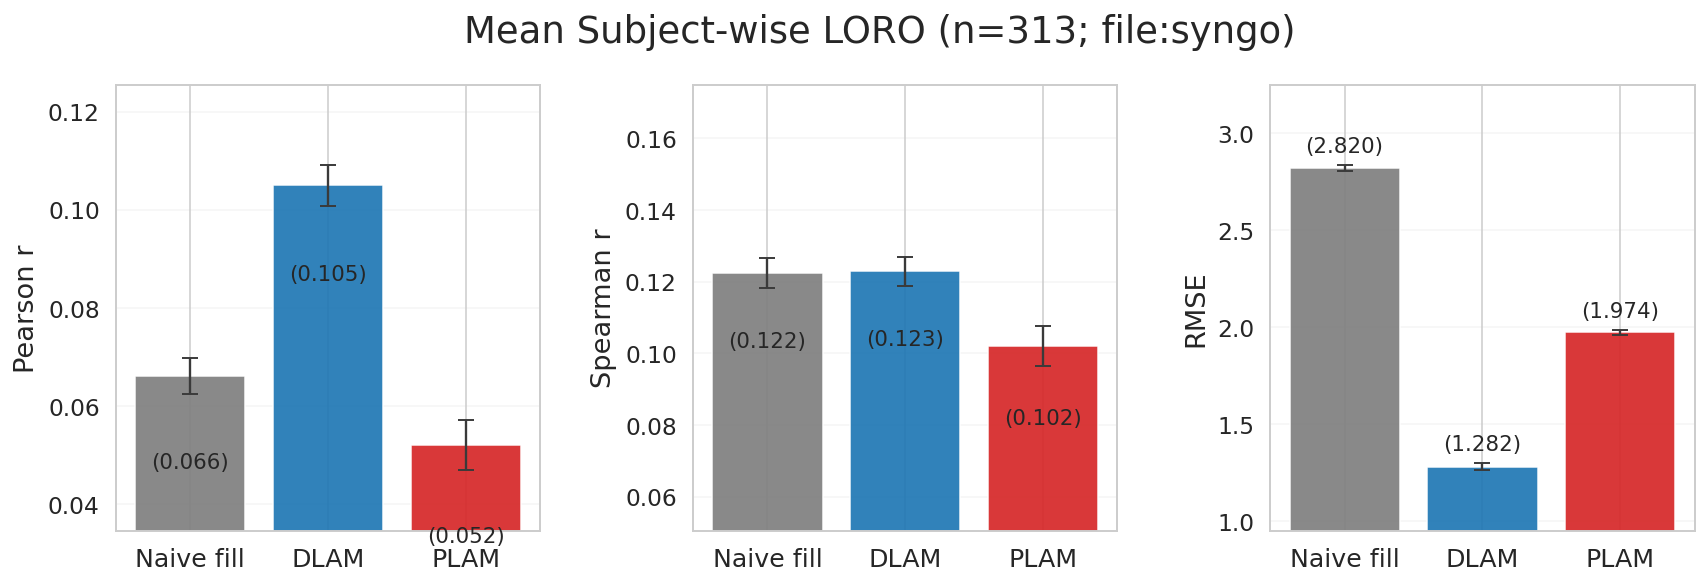

In [26]:
metrics_syngo_refz, summary_syngo_refz, pivot_syngo_refz, t_results_syngo_refz = run_mixed_space_panel(
    label='syngo | refz corr',
    mixed_space_mode=REFZ_MIXED_MODE,
    eval_gene_path='syngo',
)

## 4) Notes

This notebook intentionally focuses on mixed-space raw-truth subject-level summaries. Single-subject scatter plots remain best interpreted in the harmonized notebook.



In [30]:
print('RAW_MIXED_MODE =', RAW_MIXED_MODE)
print('REFZ_MIXED_MODE =', REFZ_MIXED_MODE)
print('REFZ_NOISE_QUANTILE =', REFZ_NOISE_QUANTILE)

RAW_MIXED_MODE = harmonized_pred_vs_raw_truth_corr
REFZ_MIXED_MODE = harmonized_pred_vs_raw_truth_refz_corr
REFZ_NOISE_QUANTILE = 0.2
